<a href="https://colab.research.google.com/drive/1tnOvFNgXiLtktiSsltTr0s308LZSsEPJ">Abre este Jupyter en Google Colab</a>

# Regresión Lineal: Coste de un incidente de seguridad 🔐💻

📘 **En este ejercicio** se explican los **fundamentos básicos de la regresión lineal** 📈 aplicados a un **caso de uso sencillo** 🧩 relacionado con la **Ciberseguridad** 🔐💻.

## Enunciado del ejercicio

🧠 **El ejercicio consiste en predecir** 📊 el **coste de un incidente de seguridad** 🔐💰 en base al **número de equipos afectados** 🖥️📉.
📦 El **conjunto de datos** es **generado de manera aleatoria** 🎲🤖.

### 1. Generación del conjunto de datos

In [1]:
import numpy as np

X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1)

print("La longitud del conjunto de datos es:", len(X))

La longitud del conjunto de datos es: 100


### 2. Visualización del conjunto de datos

In [2]:
import matplotlib.pyplot as plt

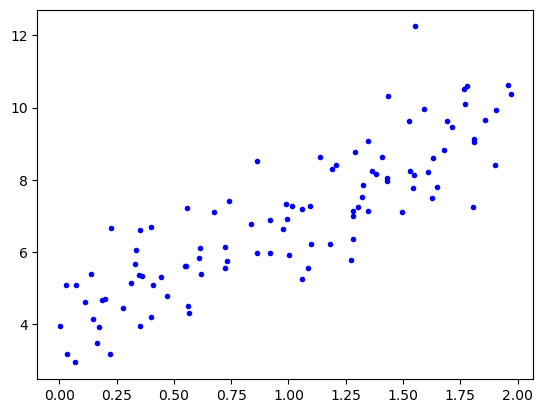

In [3]:
plt.plot(X, y, "b.")
plt.show()

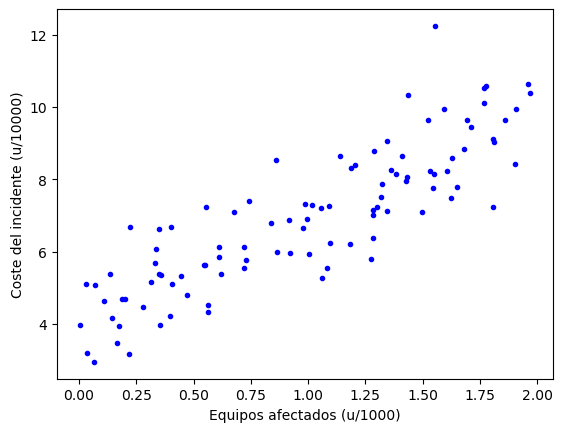

In [4]:
plt.plot(X, y, "b.")
plt.xlabel("Equipos afectados (u/1000)")
plt.ylabel("Coste del incidente (u/10000)")
plt.show()

### 3. Modificación del conjunto de datos

In [5]:
import pandas as pd

📊 **Creación del DataFrame con Pandas**

En este fragmento de código se construye un **DataFrame** utilizando la librería **Pandas**, a partir de dos conjuntos de datos:

- 🖥️ **`n_equipos_afectados`**: representa el número de equipos que se han visto afectados por un incidente de seguridad.
- 💰 **`coste`**: representa el coste económico asociado a dicho incidente.

🔧 Primero, se crea un **diccionario** (`data`) donde:
- Las **claves** son los nombres de las columnas.
- Los **valores** son los datos, que se convierten en arreglos unidimensionales usando `flatten()`.

📁 Posteriormente, el diccionario se transforma en un **DataFrame** llamado `df` mediante `pd.DataFrame(data)`.


In [6]:
data = {'n_equipos_afectados': X.flatten(), 'coste': y.flatten()}
df = pd.DataFrame(data)
df.head(10)

,n_equipos_afectados,coste
0,0.350379,6.620716
1,0.722299,6.128884
2,0.995396,6.912679
3,0.610924,5.844175
4,1.625401,7.490447
5,0.469519,4.793116
6,0.335987,6.058586
7,1.809702,9.120575
8,1.554469,12.245267
9,0.002576,3.967936


📐 **Escalado de los datos del conjunto**

En este bloque de código se realiza un **escalado de los valores** del DataFrame para trabajar con cifras más realistas y fáciles de interpretar.

---

### 🖥️ Escalado del número de equipos afectados
- 🔢 La columna **`n_equipos_afectados`** se multiplica por **1000**, simulando incidentes que afectan a un mayor número de equipos.
- 🧮 Después, los valores se convierten a tipo **entero (`int`)**, ya que no es lógico tener fracciones de equipos.

---

### 💰 Escalado del coste del incidente
- 📈 La columna **`coste`** se multiplica por **10,000**, representando costos económicos más elevados y cercanos a escenarios reales.
- 🧾 Posteriormente, los valores también se convierten a tipo **entero**, ya que el coste suele expresarse en unidades monetarias completas.



In [7]:
# Escalado del número de equipos afectados
df['n_equipos_afectados'] = df['n_equipos_afectados'] * 1000
df['n_equipos_afectados'] = df['n_equipos_afectados'].astype('int')
# Escalado del coste
df['coste'] = df['coste'] * 10000
df['coste'] = df['coste'].astype('int')
df.head(10)

,n_equipos_afectados,coste
0,350,66207
1,722,61288
2,995,69126
3,610,58441
4,1625,74904
5,469,47931
6,335,60585
7,1809,91205
8,1554,122452
9,2,39679


📈 **Representación gráfica del conjunto de datos**

En este bloque de código se realiza una **visualización gráfica** del conjunto de datos utilizando **Matplotlib**, con el objetivo de analizar la relación entre las variables.

---

### 🖥️ ¿Qué se está graficando?
- **Eje X** ➡️ `n_equipos_afectados`
  Representa la cantidad de equipos que se han visto afectados por un incidente de seguridad 🧑‍💻🖥️
- **Eje Y** ⬆️ `coste`
  Representa el coste económico asociado al incidente 💰🔐

---

### 🎨 Detalles de la gráfica
- 🔵 El marcador `"b."` indica puntos azules (*blue dots*), lo que permite observar cada incidente como un punto individual.
- 🏷️ Se añaden etiquetas a los ejes para mejorar la interpretación de la gráfica.
- 👀 `plt.show()` muestra la gráfica final en pantalla.

---

🧠 **Interpretación**
Esta visualización permite:
- Detectar **tendencias** entre el número de equipos afectados y el coste 📊
- Identificar **patrones** o **valores atípicos** 🔍
- Justificar el uso de un modelo de **regresión lineal** 📈🤖


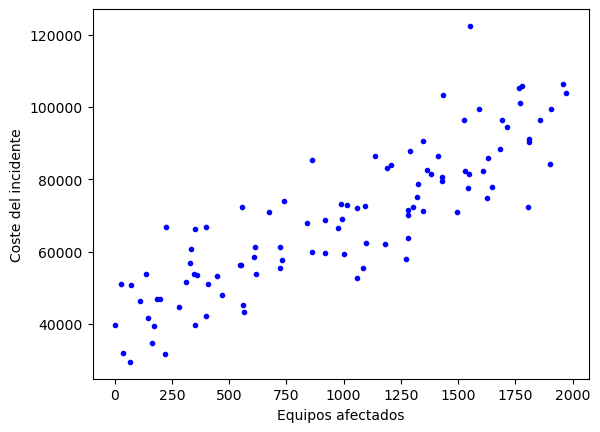

In [8]:
# Representación gráfica del conjunto de datos
plt.plot(df['n_equipos_afectados'], df['coste'], "b.")
plt.xlabel("Equipos afectados")
plt.ylabel("Coste del incidente")
plt.show()

### 4. Construcción del modelo

In [9]:
from sklearn.linear_model import LinearRegression

🤖 **Construcción del modelo de regresión lineal y ajuste de la hipótesis**

En este bloque de código se crea y entrena un **modelo de regresión lineal**, cuyo objetivo es **aprender la relación** entre el número de equipos afectados y el coste del incidente de seguridad.

---

### 🧠 Creación del modelo
- 📦 `LinearRegression()` crea una instancia del modelo de **regresión lineal** de *scikit-learn*.
- 📈 Este modelo buscará una **línea recta** que se ajuste lo mejor posible a los datos.

---

### 🔧 Entrenamiento del modelo
- 🖥️ La variable independiente (**X**) es `n_equipos_afectados`.
- 💰 La variable dependiente (**y**) es `coste`.
- 🔄 `values.reshape(-1, 1)` transforma los datos en una **matriz columna**, formato requerido por el modelo.
- ✅ `fit()` ajusta la **función hipótesis** del modelo a los datos disponibles.

---

📊 Tras este proceso, el modelo ha aprendido:
- 📐 La **pendiente** de la recta (cuánto aumenta el coste por cada equipo adicional).
- 🎯 La **ordenada al origen** (coste base cuando no hay equipos afectados).

Este modelo ya está listo para realizar **predicciones** 🔮📈


In [10]:
# Construcción del modelo y ajuste de la función hipótesis
lin_reg = LinearRegression()
lin_reg.fit(df['n_equipos_afectados'].values.reshape(-1, 1), df['coste'].values)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


📐 **Parámetro θ₀ (intercepto del modelo)**

La instrucción `lin_reg.intercept_` permite obtener el valor del **parámetro θ₀**, también conocido como el **intercepto** del modelo de regresión lineal.

---

### 🧠 ¿Qué representa θ₀?
- 📍 Es el valor del **coste del incidente** cuando el número de equipos afectados es **cero**.
- 💰 Representa un **coste base** o inicial, incluso si no hay equipos comprometidos.

---

### 📊 Interpretación en el contexto del problema
En un escenario de **Ciberseguridad** 🔐:
- θ₀ puede interpretarse como el **coste mínimo** asociado a la gestión del incidente
  (por ejemplo: análisis forense, notificación, auditorías, etc.).
- Aunque no haya equipos afectados, el incidente **sigue generando gastos**.

---

🔍 Consultar este valor es útil para:
- Entender el **comportamiento inicial** del modelo 📈
- Analizar si el modelo tiene sentido desde un punto de vista **realista** 🤔


In [11]:
# Parámetro theta 0
lin_reg.intercept_

np.float64(40184.89989430318)

📐 **Parámetro θ₁ (pendiente del modelo)**

La instrucción `lin_reg.coef_` permite obtener el valor del **parámetro θ₁**, también conocido como la **pendiente** del modelo de regresión lineal.

---

### 🧠 ¿Qué representa θ₁?
- 📈 Indica **cuánto aumenta (o disminuye) el coste del incidente** por **cada equipo adicional afectado**.
- 🔢 Es el **factor de impacto** que tiene el número de equipos comprometidos sobre el coste total.

---

### 📊 Interpretación en el contexto del problema
En términos de **Ciberseguridad** 🔐:
- θ₁ representa el **coste incremental por equipo** 🖥️💰.
- Un valor alto de θ₁ implica que **cada nuevo equipo afectado incrementa significativamente el coste** del incidente.
- Un valor bajo indica que el coste crece de manera más moderada.

---

🧩 **Relación con la función hipótesis**
La ecuación del modelo queda expresada como:

$$
\text{coste} = \theta_0 + \theta_1 \cdot (\text{n\_equipos\_afectados})
$$

---

🔍 Analizar θ₁ permite:
- Comprender la **sensibilidad del coste** frente a incidentes más grandes 📊
- Evaluar el **impacto económico del alcance del ataque** 💥💻


In [12]:
# Parámetro theta 1
lin_reg.coef_

array([29.45052623])

🔮 **Predicción para los valores mínimo y máximo del conjunto de entrenamiento**

En este bloque de código se utilizan los **valores extremos** del conjunto de datos para realizar predicciones con el modelo de **regresión lineal** previamente entrenado.

---

### 📏 Selección de valores extremos
- 📉 `df["n_equipos_afectados"].min()` obtiene el **menor número de equipos afectados** en el conjunto de datos.
- 📈 `df["n_equipos_afectados"].max()` obtiene el **mayor número de equipos afectados**.
- 🧮 Estos valores se almacenan en un arreglo `X_min_max` con el formato adecuado (**matriz columna**).

---

### 🤖 Predicción con el modelo
- 🔄 `lin_reg.predict(X_min_max)` calcula el **coste estimado** para:
  - el escenario **menos grave** 📉
  - el escenario **más grave** 📈
- 📊 El resultado se guarda en la variable `y_train_pred`.

---

🧠 **¿Para qué sirve esto?**
Este paso permite:
- Visualizar los **límites de la recta de regresión** 📐
- Comprobar si las predicciones son **coherentes** con los datos de entrenamiento ✅
- Analizar el **impacto económico** entre incidentes pequeños y grandes 🔐💰


In [13]:
# Predicción para el valor mínimo y máximo del conjunto de datos de entrenamiento
X_min_max = np.array([[df["n_equipos_afectados"].min()], [df["n_equipos_afectados"].max()]])
y_train_pred = lin_reg.predict(X_min_max)

📈 **Representación gráfica de la función hipótesis**

En este bloque de código se muestra de forma visual la **función hipótesis** generada por el modelo de **regresión lineal**, superpuesta sobre el conjunto de datos original.

---

### 🟢 Recta de regresión (función hipótesis)
- `plt.plot(X_min_max, y_train_pred, "g-")` dibuja la **recta de regresión** en color verde.
- Esta línea representa la **relación aprendida** por el modelo entre:
  - 🖥️ el número de equipos afectados
  - 💰 el coste del incidente

---

### 🔵 Datos reales
- `plt.plot(df['n_equipos_afectados'], df['coste'], "b.")` muestra los **datos reales** como puntos azules.
- Cada punto representa un **incidente de seguridad observado** 🔐.

---

### 🏷️ Etiquetas y visualización
- Se añaden etiquetas a los ejes para mejorar la **interpretación de la gráfica**.
- `plt.show()` muestra la gráfica final.

---

🧠 **Interpretación**
Esta representación permite:
- Ver qué tan bien la **recta se ajusta a los datos** 📊
- Evaluar visualmente la **calidad del modelo** ✅
- Comprender cómo el coste del incidente **aumenta conforme crece el número de equipos afectados** 📈💻


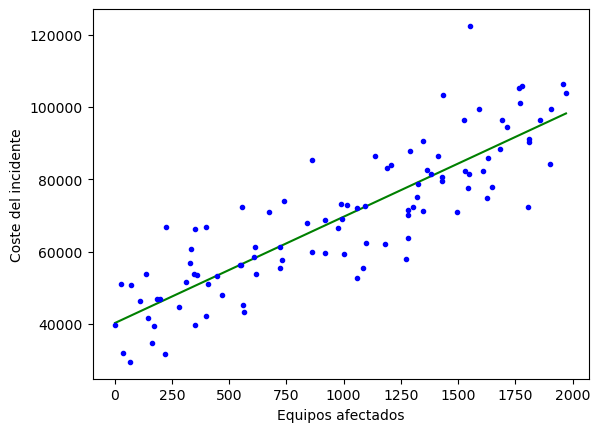

In [14]:
# Representación gráfica de la función hipótesis generada
plt.plot(X_min_max, y_train_pred, "g-")
plt.plot(df['n_equipos_afectados'], df['coste'], "b.")
plt.xlabel("Equipos afectados")
plt.ylabel("Coste del incidente")
plt.show()

### 5. Predicción de nuevos ejemplos

🔮 **Predicción del coste para un nuevo incidente de seguridad**

En este bloque de código se realiza una **predicción concreta** utilizando el modelo de **regresión lineal** ya entrenado.

---

### 🖥️ Definición del nuevo escenario
- `x_new = np.array([[1300]])` representa un **nuevo incidente** en el que se ven afectados **1300 equipos**.
- 📐 El valor se define como una **matriz columna**, formato requerido por el modelo.

---

### 🤖 Predicción con el modelo entrenado
- `lin_reg.predict(x_new)` calcula el **coste estimado** del incidente para ese número de equipos afectados.
- 💾 El resultado se almacena en la variable `coste`.

---

### 🖨️ Presentación del resultado
- Se convierte el valor a **entero** para mostrarlo de forma clara.
- 📢 Se imprime el **coste aproximado del incidente** en euros (€).

---

🧠 **Interpretación**
Esta predicción permite:
- Estimar el **impacto económico** de un incidente real 🔐💰
- Apoyar la **toma de decisiones** en ciberseguridad 📊
- Comprender cómo el modelo extrapola información a **nuevos casos** 🔍


In [15]:
x_new = np.array([[1300]]) # 1300 equipos afectados

# Predicción del coste que tendría el incidente
coste = lin_reg.predict(x_new) 

print("El coste del incidente sería:", int(coste[0]), "€")

El coste del incidente sería: 78470 €


📊 **Visualización final: datos, modelo y predicción**

En este bloque de código se presenta una **gráfica completa** que combina:
- los **datos reales**,
- la **función hipótesis** aprendida por el modelo,
- y una **predicción específica** para un nuevo incidente.

---

### 🔵 Datos reales
- `plt.plot(df['n_equipos_afectados'], df['coste'], "b.")`
  Muestra el conjunto de datos original como **puntos azules**.
- Cada punto representa un **incidente de seguridad observado** 🔐🖥️.

---

### 🟢 Función hipótesis (modelo entrenado)
- `plt.plot(X_min_max, y_train_pred, "g-")`
  Dibuja la **recta de regresión** en color verde.
- Representa la **relación lineal** entre el número de equipos afectados y el coste 📈.

---

### ❌ Predicción para un nuevo caso
- `plt.plot(x_new, coste, "rx")`
  Marca en rojo la **predicción del modelo** para un incidente con **1300 equipos afectados**.
- El símbolo ❌ permite identificar fácilmente el **valor estimado** 🔮💰.

---

### 🏷️ Etiquetas y visualización
- Se añaden etiquetas a los ejes para facilitar la interpretación.
- `plt.show()` muestra la gráfica final.

---

🧠 **Conclusión**
Esta visualización permite:
- Comparar **datos reales vs. modelo** 📊
- Ver cómo el modelo **generaliza** a nuevos escenarios 🔍
- Entender gráficamente el **impacto económico** de incidentes de gran escala 🔐💥


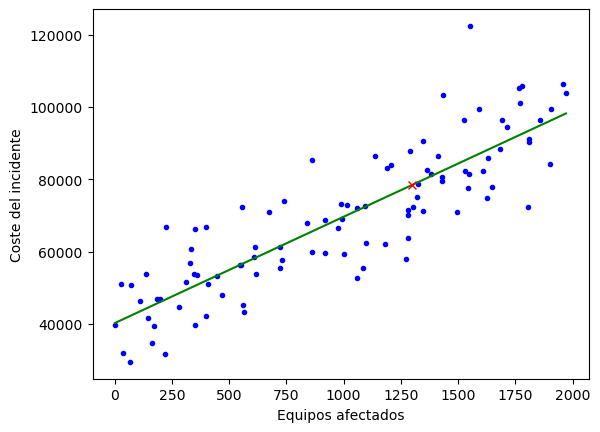

In [16]:
plt.plot(df['n_equipos_afectados'], df['coste'], "b.")
plt.plot(X_min_max, y_train_pred, "g-")
plt.plot(x_new, coste, "rx")
plt.xlabel("Equipos afectados")
plt.ylabel("Coste del incidente")
plt.show()